Caricamento tabelle...
  patient:          2,520 righe
  apachePredVar:    2,205 righe
  respiratoryCare:  5,436 righe

DIAGNOSTICA respiratoryCare

airwaytype missing: 4,642 / 5,436 (85.4%)

Distribuzione airwaytype (inclusi NaN):
airwaytype
NaN                     4642
Oral ETT                 567
No Artificial Airway     217
Tracheostomy               9
Other                      1

ventstartoffset:
  < 0  (pre-ICU):     874 record
  = 0  (t0):          4,288 record
  0–1440min (finestra): 115 record

⚠️  CONCLUSIONE: airwaytype è 85% missing →
   respiratoryCare NON è affidabile come fonte primaria di A.
   Usa apachePredVar (oobintubday1) come definizione principale.

Pazienti primo stay: 2,119

PAZIENTI PRE-INTUBATI (candidati all'esclusione)

Pazienti con airwaytype invasivo e ventstartoffset < 0: 39
→ Questi erano già intubati prima dell'ICU
→ Valuta se escluderli dalla coorte (t0 non definibile)

FONTE PRIMARIA: apachePredVar → oobintubday1

oobintubday1 missing: 0 / 2,029 (0.

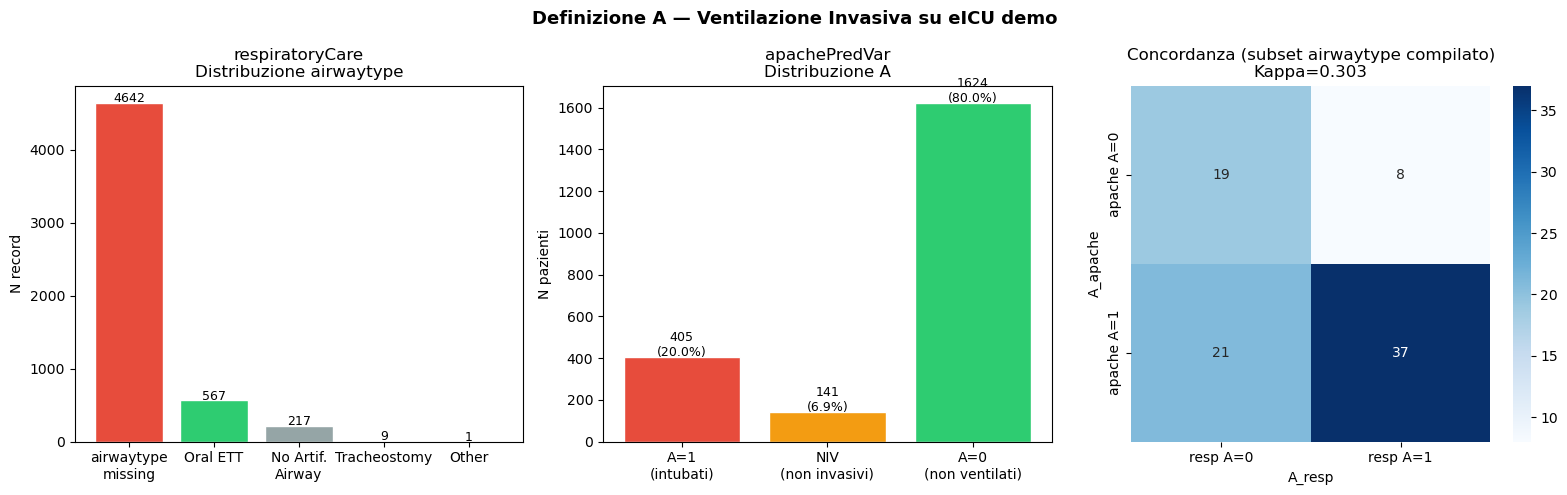

In [11]:
"""
Definizione di A (ventilazione invasiva) su eICU demo
Fonti: apachePredVar (primaria) + respiratoryCare (verifica)

Risultati diagnostica respiratoryCare:
  - airwaytype: 85% missing → NON affidabile come fonte primaria
  - ventstartoffset: 874 record < 0 (intubati pre-ICU → da escludere dalla coorte)
  - Valori invasivi trovati: "Oral ETT" (567), "Tracheostomy" (9)

Conclusione: usa oobintubday1 da apachePredVar come definizione primaria di A.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score

# ─────────────────────────────────────────
# 0. CONFIGURAZIONE
# ─────────────────────────────────────────
DATA_PATH      = "../data/raw/"
VENT_WINDOW_H  = 24
VENT_WINDOW_MIN = VENT_WINDOW_H * 60

# ─────────────────────────────────────────
# 1. CARICA LE TABELLE
# ─────────────────────────────────────────
print("Caricamento tabelle...")

patient = pd.read_csv(f"{DATA_PATH}patient.csv",
                      usecols=["patientunitstayid", "unitvisitnumber"])

apache = pd.read_csv(f"{DATA_PATH}apachePredVar.csv",
                     usecols=["patientunitstayid", "oobintubday1", "oobventday1"])

resp = pd.read_csv(f"{DATA_PATH}respiratoryCare.csv",
                   usecols=["patientunitstayid", "airwaytype", "ventstartoffset"])

print(f"  patient:          {len(patient):,} righe")
print(f"  apachePredVar:    {len(apache):,} righe")
print(f"  respiratoryCare:  {len(resp):,} righe")

# ─────────────────────────────────────────
# 2. DIAGNOSTICA respiratoryCare
# ─────────────────────────────────────────
print("\n" + "="*55)
print("DIAGNOSTICA respiratoryCare")
print("="*55)

n_resp = len(resp)
n_missing_airway = resp["airwaytype"].isna().sum()
print(f"\nairwaytype missing: {n_missing_airway:,} / {n_resp:,} "
      f"({n_missing_airway/n_resp*100:.1f}%)")
print("\nDistribuzione airwaytype (inclusi NaN):")
print(resp["airwaytype"].value_counts(dropna=False).to_string())

print(f"\nventstartoffset:")
print(f"  < 0  (pre-ICU):     {(resp['ventstartoffset'] < 0).sum():,} record")
print(f"  = 0  (t0):          {(resp['ventstartoffset'] == 0).sum():,} record")
print(f"  0–{VENT_WINDOW_MIN}min (finestra): "
      f"{((resp['ventstartoffset'] > 0) & (resp['ventstartoffset'] <= VENT_WINDOW_MIN)).sum():,} record")

print("\n⚠️  CONCLUSIONE: airwaytype è 85% missing →")
print("   respiratoryCare NON è affidabile come fonte primaria di A.")
print("   Usa apachePredVar (oobintubday1) come definizione principale.")

# ─────────────────────────────────────────
# 3. COORTE BASE: solo primo ICU stay
# ─────────────────────────────────────────
primo_stay = patient[patient["unitvisitnumber"] == 1]["patientunitstayid"]
print(f"\nPazienti primo stay: {len(primo_stay):,}")

# ─────────────────────────────────────────
# 4. IDENTIFICAZIONE PAZIENTI PRE-INTUBATI
#    (da escludere dalla coorte → t0 non pulito)
# ─────────────────────────────────────────
print("\n" + "="*55)
print("PAZIENTI PRE-INTUBATI (candidati all'esclusione)")
print("="*55)

resp_primo = resp[resp["patientunitstayid"].isin(primo_stay)]

# Pazienti con record di intubazione PRIMA dell'ICU
pre_intubati = resp_primo[
    resp_primo["airwaytype"].isin(["Oral ETT", "Tracheostomy"]) &
    (resp_primo["ventstartoffset"] < 0)
]["patientunitstayid"].unique()

print(f"\nPazienti con airwaytype invasivo e ventstartoffset < 0: {len(pre_intubati):,}")
print("→ Questi erano già intubati prima dell'ICU")
print("→ Valuta se escluderli dalla coorte (t0 non definibile)")

# ─────────────────────────────────────────
# 5. FONTE PRIMARIA: apachePredVar
# ─────────────────────────────────────────
print("\n" + "="*55)
print("FONTE PRIMARIA: apachePredVar → oobintubday1")
print("="*55)

apache = apache[apache["patientunitstayid"].isin(primo_stay)]

# Gestisci missing in oobintubday1
n_missing_intub = apache["oobintubday1"].isna().sum()
print(f"\noobintubday1 missing: {n_missing_intub:,} / {len(apache):,} "
      f"({n_missing_intub/len(apache)*100:.1f}%)")

apache["A_apache"]   = (apache["oobintubday1"] == 1).astype(int)
apache["NIV_apache"] = (
    (apache["oobventday1"] == 1) & (apache["oobintubday1"] != 1)
).astype(int)

print(f"\nA=1 (intubati invasivi):  {apache['A_apache'].sum():,}  "
      f"({apache['A_apache'].mean()*100:.1f}%)")
print(f"NIV (non invasivi):       {apache['NIV_apache'].sum():,}  "
      f"({apache['NIV_apache'].mean()*100:.1f}%)")
print(f"A=0 (non ventilati):      {(apache['A_apache'] == 0).sum():,}  "
      f"({(apache['A_apache']==0).mean()*100:.1f}%)")

# ─────────────────────────────────────────
# 6. FONTE VERIFICA: respiratoryCare
#    (solo sui record con airwaytype non-missing)
# ─────────────────────────────────────────
print("\n" + "="*55)
print("FONTE VERIFICA: respiratoryCare (non-missing only)")
print("="*55)

INVASIVE_TYPES = ["Oral ETT", "Tracheostomy"]

resp_invasive = resp_primo[
    resp_primo["airwaytype"].isin(INVASIVE_TYPES) &
    (resp_primo["ventstartoffset"] >= 0) &
    (resp_primo["ventstartoffset"] <= VENT_WINDOW_MIN)
]

resp_invasive_first = (
    resp_invasive
    .sort_values("ventstartoffset")
    .groupby("patientunitstayid")
    .first()
    .reset_index()
    [["patientunitstayid", "airwaytype", "ventstartoffset"]]
)
resp_invasive_first["A_resp"] = 1

print(f"\nA=1 da respiratoryCare (finestra {VENT_WINDOW_H}h): "
      f"{len(resp_invasive_first):,}")
print("(Numero basso atteso: 85% di airwaytype è missing)")

# ─────────────────────────────────────────
# 7. CONCORDANZA (sui pazienti con entrambe le info)
# ─────────────────────────────────────────
print("\n" + "="*55)
print("CONCORDANZA (solo pazienti con airwaytype non-missing)")
print("="*55)

# Pazienti che hanno almeno un record con airwaytype non-missing
pazienti_con_airway = resp_primo[
    resp_primo["airwaytype"].notna()
]["patientunitstayid"].unique()

print(f"\nPazienti con almeno un airwaytype compilato: {len(pazienti_con_airway):,}")

df_check = apache[
    apache["patientunitstayid"].isin(pazienti_con_airway)
][["patientunitstayid", "A_apache"]].copy()

df_check = df_check.merge(
    resp_invasive_first[["patientunitstayid", "A_resp"]],
    on="patientunitstayid", how="left"
)
df_check["A_resp"] = df_check["A_resp"].fillna(0).astype(int)

n      = len(df_check)
conc1  = ((df_check["A_apache"] == 1) & (df_check["A_resp"] == 1)).sum()
s_apa  = ((df_check["A_apache"] == 1) & (df_check["A_resp"] == 0)).sum()
s_res  = ((df_check["A_apache"] == 0) & (df_check["A_resp"] == 1)).sum()
conc0  = ((df_check["A_apache"] == 0) & (df_check["A_resp"] == 0)).sum()

print(f"\nTabella di contingenza (N={n}):")
print(pd.crosstab(df_check["A_apache"], df_check["A_resp"],
                  rownames=["apache"], colnames=["resp"], margins=True))

kappa = cohen_kappa_score(df_check["A_apache"], df_check["A_resp"])
accordo = (conc1 + conc0) / n
print(f"\nAccordo totale: {accordo*100:.1f}%")
print(f"Cohen's Kappa:  {kappa:.3f}  ", end="")
if   kappa > 0.8: print("→ Ottima concordanza ✅")
elif kappa > 0.6: print("→ Buona concordanza")
elif kappa > 0.4: print("→ Concordanza moderata ⚠️")
else:             print("→ Concordanza scarsa ❌")

# ─────────────────────────────────────────
# 8. FIGURE
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Definizione A — Ventilazione Invasiva su eICU demo",
             fontsize=13, fontweight="bold")

# Plot 1: Missing in respiratoryCare
labels1  = ["airwaytype\nmissing", "Oral ETT", "No Artif.\nAirway",
            "Tracheostomy", "Other"]
values1  = resp["airwaytype"].value_counts(dropna=False).values
colors1  = ["#e74c3c", "#2ecc71", "#95a5a6", "#27ae60", "#bdc3c7"]
axes[0].bar(labels1, values1, color=colors1, edgecolor="white")
axes[0].set_title("respiratoryCare\nDistribuzione airwaytype")
axes[0].set_ylabel("N record")
for i, v in enumerate(values1):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=9)

# Plot 2: Distribuzione A da apachePredVar
labels2 = ["A=1\n(intubati)", "NIV\n(non invasivi)", "A=0\n(non ventilati)"]
values2 = [apache["A_apache"].sum(), apache["NIV_apache"].sum(),
           (apache["A_apache"] == 0).sum()]
colors2 = ["#e74c3c", "#f39c12", "#2ecc71"]
axes[1].bar(labels2, values2, color=colors2, edgecolor="white")
axes[1].set_title("apachePredVar\nDistribuzione A")
axes[1].set_ylabel("N pazienti")
for i, v in enumerate(values2):
    pct = v / len(apache) * 100
    axes[1].text(i, v + 5, f"{v}\n({pct:.1f}%)", ha="center", fontsize=9)

# Plot 3: Heatmap concordanza (subset con airwaytype)
conf_matrix = pd.crosstab(df_check["A_apache"], df_check["A_resp"])
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["resp A=0", "resp A=1"],
            yticklabels=["apache A=0", "apache A=1"])
axes[2].set_title(f"Concordanza (subset airwaytype compilato)\nKappa={kappa:.3f}")

plt.tight_layout()
plt.savefig("../output_png/concordanza_ventilazione.png", dpi=150, bbox_inches="tight")
print("\nFigura salvata: concordanza_ventilazione.png")

# ─────────────────────────────────────────
# 9. DEFINIZIONE FINALE E RACCOMANDAZIONE
# ─────────────────────────────────────────
print("\n" + "="*55)
print("DEFINIZIONE FINALE DI A — RACCOMANDAZIONE")
print("="*55)

df_final = apache[["patientunitstayid", "A_apache", "NIV_apache"]].copy()
df_final = df_final.rename(columns={"A_apache": "A_final"})

print(f"""
SCELTA: A = oobintubday1 da apachePredVar

Motivazione:
  1. airwaytype in respiratoryCare è 85% missing
     → non rappresenta la popolazione reale
  2. oobintubday1 è calcolato sistematicamente
     per tutti i pazienti come parte di APACHE
  3. La concordanza sul subset disponibile
     (Kappa={kappa:.3f}) conferma la coerenza

Pazienti da considerare per esclusione dalla coorte:
  - Pre-intubati (ventstartoffset < 0): {len(pre_intubati):,}
  - apache missing (oobintubday1 NaN):   {n_missing_intub:,}

Dataset finale:
  A=1 (ventilati invasivi): {df_final['A_final'].sum():,}
  A=0 (non ventilati):      {(df_final['A_final']==0).sum():,}
  Totale:                   {len(df_final):,}
""")

print("Script completato.")

COORTE (primo ICU stay)
  Pazienti totali nel dataset:    2,520
  Pazienti primo stay (coorte):   2,119
  Con record in apachePredVar:    2,029  (95.8%)
  Senza record in apachePredVar:  90  (4.2%)  ← missing intera riga
  Con almeno 1 record in resp:    341  (16.1%)

MISSING: apachePredVar → oobintubday1

  Righe in apachePredVar (primo stay):  2,029
  oobintubday1  — missing: 0  (0.0%)  | valido: 2,029  (100.0%)
  oobventday1   — missing: 0  (0.0%)

  Valori unici di oobintubday1:
 valore  conteggio
      0       1624
      1        405

  → A=1 (intubati):     405  (20.0%)
  → A=0 (non intubati): 1,624  (80.0%)
  → Missing (ignoti):   0  (0.0%)

MISSING: respiratoryCare → airwaytype

  Righe totali in respiratoryCare:    4,178
  Pazienti unici con almeno 1 riga:   341
  airwaytype — missing: 3,542  (84.8%)  | valido: 636  (15.2%)

  Distribuzione airwaytype (inclusi NaN):
              valore  conteggio
                 NaN       3542
            Oral ETT        479
No Artificial Ai

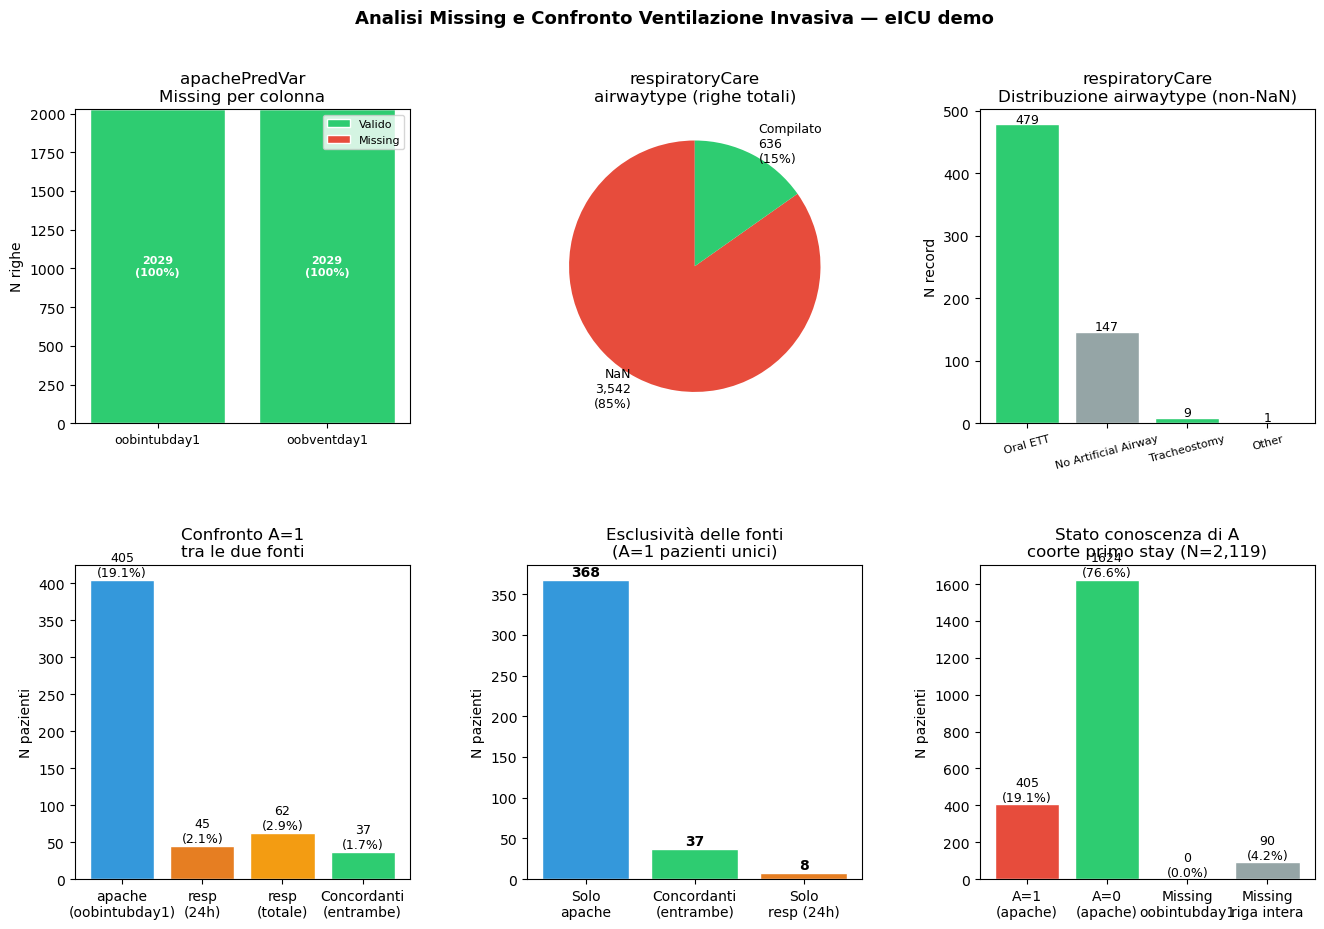

In [3]:
"""
Analisi missing data e confronto numerico ventilazione invasiva
Tabelle: apachePredVar (oobintubday1) vs respiratoryCare (airwaytype)
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ─────────────────────────────────────────
# 0. CONFIGURAZIONE
# ─────────────────────────────────────────
DATA_PATH       = "../data/raw/"
VENT_WINDOW_MIN = 24 * 60   # 24h in minuti
INVASIVE_TYPES  = ["Oral ETT", "Tracheostomy"]

# ─────────────────────────────────────────
# 1. CARICA TABELLE
# ─────────────────────────────────────────
patient = pd.read_csv(f"{DATA_PATH}patient.csv",
                      usecols=["patientunitstayid", "unitvisitnumber"])

apache  = pd.read_csv(f"{DATA_PATH}apachePredVar.csv",
                      usecols=["patientunitstayid", "oobintubday1", "oobventday1"])

resp    = pd.read_csv(f"{DATA_PATH}respiratoryCare.csv",
                      usecols=["patientunitstayid", "airwaytype", "ventstartoffset"])

# Coorte: solo primo stay
primo_stay = patient[patient["unitvisitnumber"] == 1]["patientunitstayid"]
N_coorte   = len(primo_stay)

apache = apache[apache["patientunitstayid"].isin(primo_stay)]
resp   = resp[resp["patientunitstayid"].isin(primo_stay)]

print("=" * 60)
print("COORTE (primo ICU stay)")
print("=" * 60)
print(f"  Pazienti totali nel dataset:    {len(patient):,}")
print(f"  Pazienti primo stay (coorte):   {N_coorte:,}")
print(f"  Con record in apachePredVar:    {len(apache):,}  "
      f"({len(apache)/N_coorte*100:.1f}%)")
print(f"  Senza record in apachePredVar:  {N_coorte - len(apache):,}  "
      f"({(N_coorte - len(apache))/N_coorte*100:.1f}%)  ← missing intera riga")
print(f"  Con almeno 1 record in resp:    "
      f"{resp['patientunitstayid'].nunique():,}  "
      f"({resp['patientunitstayid'].nunique()/N_coorte*100:.1f}%)")


# ─────────────────────────────────────────
# 2. MISSING SU apachePredVar → oobintubday1
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("MISSING: apachePredVar → oobintubday1")
print("=" * 60)

n_apache     = len(apache)
miss_intub   = apache["oobintubday1"].isna().sum()
miss_vent    = apache["oobventday1"].isna().sum()
valid_intub  = n_apache - miss_intub

print(f"\n  Righe in apachePredVar (primo stay):  {n_apache:,}")
print(f"  oobintubday1  — missing: {miss_intub:,}  "
      f"({miss_intub/n_apache*100:.1f}%)  "
      f"| valido: {valid_intub:,}  ({valid_intub/n_apache*100:.1f}%)")
print(f"  oobventday1   — missing: {miss_vent:,}  "
      f"({miss_vent/n_apache*100:.1f}%)")

# Distribuzione valori oobintubday1
print(f"\n  Valori unici di oobintubday1:")
print(apache["oobintubday1"].value_counts(dropna=False)
      .rename_axis("valore").reset_index(name="conteggio")
      .to_string(index=False))

# Stima A=1 da apache
A1_apache      = (apache["oobintubday1"] == 1).sum()
A0_apache      = (apache["oobintubday1"] == 0).sum()
Amiss_apache   = miss_intub

print(f"\n  → A=1 (intubati):     {A1_apache:,}  ({A1_apache/n_apache*100:.1f}%)")
print(f"  → A=0 (non intubati): {A0_apache:,}  ({A0_apache/n_apache*100:.1f}%)")
print(f"  → Missing (ignoti):   {Amiss_apache:,}  ({Amiss_apache/n_apache*100:.1f}%)")


# ─────────────────────────────────────────
# 3. MISSING SU respiratoryCare → airwaytype
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("MISSING: respiratoryCare → airwaytype")
print("=" * 60)

n_resp_pazienti = resp["patientunitstayid"].nunique()
n_resp_righe    = len(resp)
miss_airway     = resp["airwaytype"].isna().sum()
valid_airway    = n_resp_righe - miss_airway

print(f"\n  Righe totali in respiratoryCare:    {n_resp_righe:,}")
print(f"  Pazienti unici con almeno 1 riga:   {n_resp_pazienti:,}")
print(f"  airwaytype — missing: {miss_airway:,}  "
      f"({miss_airway/n_resp_righe*100:.1f}%)  "
      f"| valido: {valid_airway:,}  ({valid_airway/n_resp_righe*100:.1f}%)")

print(f"\n  Distribuzione airwaytype (inclusi NaN):")
print(resp["airwaytype"].value_counts(dropna=False)
      .rename_axis("valore").reset_index(name="conteggio")
      .to_string(index=False))

# Pazienti che hanno SOLO record con airwaytype NaN
pazienti_solo_nan = (
    resp.groupby("patientunitstayid")["airwaytype"]
    .apply(lambda x: x.isna().all())
)
n_solo_nan = pazienti_solo_nan.sum()
print(f"\n  Pazienti con TUTTI i record airwaytype NaN: {n_solo_nan:,}  "
      f"({n_solo_nan/n_resp_pazienti*100:.1f}%)")

# Stima A=1 da resp (finestra 24h)
resp_inv = resp[
    resp["airwaytype"].isin(INVASIVE_TYPES) &
    (resp["ventstartoffset"] >= 0) &
    (resp["ventstartoffset"] <= VENT_WINDOW_MIN)
]
A1_resp = resp_inv["patientunitstayid"].nunique()

# Stima A=1 da resp (senza filtro temporale — quanti in totale)
A1_resp_notot = resp[
    resp["airwaytype"].isin(INVASIVE_TYPES)
]["patientunitstayid"].nunique()

print(f"\n  → A=1 nella finestra 24h:   {A1_resp:,} pazienti unici")
print(f"  → A=1 in qualsiasi momento: {A1_resp_notot:,} pazienti unici")


# ─────────────────────────────────────────
# 4. CONFRONTO NUMERICO TRA LE DUE FONTI
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("CONFRONTO NUMERICO: A=1 nelle due fonti")
print("=" * 60)

# Costruisci set di patientunitstayid per ogni categoria
set_A1_apache = set(
    apache[apache["oobintubday1"] == 1]["patientunitstayid"]
)
set_A1_resp = set(
    resp_inv["patientunitstayid"]
)
set_A1_resp_all = set(
    resp[resp["airwaytype"].isin(INVASIVE_TYPES)]["patientunitstayid"]
)

# Intersezioni
in_entrambe   = set_A1_apache & set_A1_resp
solo_apache   = set_A1_apache - set_A1_resp
solo_resp     = set_A1_resp   - set_A1_apache

print(f"""
  Fonte             │  N pazienti A=1
  ──────────────────┼──────────────────────────────
  apachePredVar     │  {len(set_A1_apache):>5,}  (oobintubday1=1, finestra 24h APACHE)
  respiratoryCare   │  {len(set_A1_resp):>5,}  (Oral ETT / Tracheostomy, offset 0-1440min)
  respiratoryCare*  │  {len(set_A1_resp_all):>5,}  (*senza filtro temporale)
  ──────────────────┼──────────────────────────────
  In entrambe       │  {len(in_entrambe):>5,}  ← concordanti
  Solo apache       │  {len(solo_apache):>5,}  ← catturati solo da apache
  Solo resp (24h)   │  {len(solo_resp):>5,}  ← catturati solo da resp
""")

# Pazienti apache missing (non in apache ma nel primo stay)
not_in_apache = set(primo_stay) - set(apache["patientunitstayid"])
print(f"  Pazienti primo stay NON in apachePredVar: {len(not_in_apache):,}")
print(f"  → Trattati come missing (ignoti per A)")
print(f"  → NON assumere A=0 per questi pazienti!")

# Overlap tra missing apache e resp invasivi
missing_ma_resp_inv = not_in_apache & set_A1_resp_all
print(f"\n  Di questi {len(not_in_apache)} missing in apache:")
print(f"  → {len(missing_ma_resp_inv):,} hanno un record invasivo in respiratoryCare")
print(f"     (potenziali A=1 non catturati da apache)")


# ─────────────────────────────────────────
# 5. TABELLA RIASSUNTIVA FINALE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("TABELLA RIASSUNTIVA — COORTE PRIMO STAY")
print("=" * 60)

print(f"""
  Categoria                              N        %
  ─────────────────────────────────────────────────
  Coorte (primo stay)               {N_coorte:>6,}   100.0%

  Con dati apache:                  {len(apache):>6,}   {len(apache)/N_coorte*100:.1f}%
    → A=1 (intubati)                {A1_apache:>6,}   {A1_apache/N_coorte*100:.1f}%
    → A=0 (non intubati)            {A0_apache:>6,}   {A0_apache/N_coorte*100:.1f}%
    → oobintubday1 NaN              {Amiss_apache:>6,}   {Amiss_apache/N_coorte*100:.1f}%

  Senza record apache (riga intera) {len(not_in_apache):>6,}   {len(not_in_apache)/N_coorte*100:.1f}%
    → di cui con resp invasivo      {len(missing_ma_resp_inv):>6,}   {len(missing_ma_resp_inv)/N_coorte*100:.1f}%

  A=1 da apache (definitivo)        {A1_apache:>6,}   {A1_apache/N_coorte*100:.1f}%
  A=1 da resp (finestra 24h)        {A1_resp:>6,}   {A1_resp/N_coorte*100:.1f}%
  A=1 concordanti (entrambe)        {len(in_entrambe):>6,}   {len(in_entrambe)/N_coorte*100:.1f}%
""")


# ─────────────────────────────────────────
# 6. FIGURE
# ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Analisi Missing e Confronto Ventilazione Invasiva — eICU demo",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Missing per colonna (apache)
ax1 = fig.add_subplot(gs[0, 0])
cols_apache  = ["oobintubday1", "oobventday1"]
miss_apache  = [apache[c].isna().sum() for c in cols_apache]
valid_apache = [n_apache - m for m in miss_apache]
x = np.arange(len(cols_apache))
ax1.bar(x, valid_apache, label="Valido",  color="#2ecc71", edgecolor="white")
ax1.bar(x, miss_apache,  label="Missing", color="#e74c3c", edgecolor="white",
        bottom=valid_apache)
ax1.set_xticks(x); ax1.set_xticklabels(cols_apache, fontsize=9)
ax1.set_title("apachePredVar\nMissing per colonna")
ax1.set_ylabel("N righe")
ax1.legend(fontsize=8)
for i, (v, m) in enumerate(zip(valid_apache, miss_apache)):
    ax1.text(i, v/2,   f"{v}\n({v/n_apache*100:.0f}%)",
             ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    if m > 0:
        ax1.text(i, v + m/2, f"{m}\n({m/n_apache*100:.0f}%)",
                 ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# ── Plot 2: Missing airwaytype (resp) — torta
ax2 = fig.add_subplot(gs[0, 1])
sizes  = [miss_airway, valid_airway]
labels = [f"NaN\n{miss_airway:,}\n({miss_airway/n_resp_righe*100:.0f}%)",
          f"Compilato\n{valid_airway:,}\n({valid_airway/n_resp_righe*100:.0f}%)"]
ax2.pie(sizes, labels=labels, colors=["#e74c3c", "#2ecc71"],
        startangle=90, textprops={"fontsize": 9})
ax2.set_title("respiratoryCare\nairwaytype (righe totali)")

# ── Plot 3: Distribuzione airwaytype non-NaN
ax3 = fig.add_subplot(gs[0, 2])
vc = resp["airwaytype"].value_counts(dropna=True)
colors3 = ["#2ecc71" if v in INVASIVE_TYPES else "#95a5a6" for v in vc.index]
ax3.bar(vc.index, vc.values, color=colors3, edgecolor="white")
ax3.set_title("respiratoryCare\nDistribuzione airwaytype (non-NaN)")
ax3.set_ylabel("N record")
ax3.tick_params(axis="x", rotation=15, labelsize=8)
for i, v in enumerate(vc.values):
    ax3.text(i, v + 2, str(v), ha="center", fontsize=9)

# ── Plot 4: Confronto A=1 tra le fonti
ax4 = fig.add_subplot(gs[1, 0])
fonti  = ["apache\n(oobintubday1)", "resp\n(24h)", "resp\n(totale)", "Concordanti\n(entrambe)"]
valori = [len(set_A1_apache), A1_resp, A1_resp_notot, len(in_entrambe)]
colors4 = ["#3498db", "#e67e22", "#f39c12", "#2ecc71"]
bars = ax4.bar(fonti, valori, color=colors4, edgecolor="white")
ax4.set_title("Confronto A=1\ntra le due fonti")
ax4.set_ylabel("N pazienti")
for bar, v in zip(bars, valori):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{v}\n({v/N_coorte*100:.1f}%)", ha="center", va="bottom", fontsize=9)

# ── Plot 5: Venn-like — esclusività delle fonti
ax5 = fig.add_subplot(gs[1, 1])
categorie = ["Solo\napache", "Concordanti\n(entrambe)", "Solo\nresp (24h)"]
val5      = [len(solo_apache), len(in_entrambe), len(solo_resp)]
col5      = ["#3498db", "#2ecc71", "#e67e22"]
bars5 = ax5.bar(categorie, val5, color=col5, edgecolor="white")
ax5.set_title("Esclusività delle fonti\n(A=1 pazienti unici)")
ax5.set_ylabel("N pazienti")
for bar, v in zip(bars5, val5):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(v), ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Plot 6: Stato conoscenza A per tutta la coorte
ax6 = fig.add_subplot(gs[1, 2])
stati  = ["A=1\n(apache)", "A=0\n(apache)", "Missing\noobintubday1",
          "Missing\nriga intera"]
val6   = [A1_apache, A0_apache, Amiss_apache, len(not_in_apache)]
col6   = ["#e74c3c", "#2ecc71", "#f39c12", "#95a5a6"]
bars6  = ax6.bar(stati, val6, color=col6, edgecolor="white")
ax6.set_title(f"Stato conoscenza di A\ncoorte primo stay (N={N_coorte:,})")
ax6.set_ylabel("N pazienti")
for bar, v in zip(bars6, val6):
    pct = v / N_coorte * 100
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.savefig("../output_png/missing_ventilation_analysis.png",
            dpi=150, bbox_inches="tight")
print("\nFigura salvata: missing_ventilation_analysis.png")
print("Script completato.")

In [1]:
# Quanti pazienti hanno diagnosi infettiva?
# Questo determina la fattibilità dello studio

admissiondx[
    admissiondx['admitdxpath'].str.contains(
        'infect|sepsis|pneumonia|bacteremia',
        case=False, na=False
    )
]['patientunitstayid'].nunique()

NameError: name 'admissiondx' is not defined

STEP 0 — Configurazione
  Finestra trattamento: 24h
  Finestra vitali basali: 120min
  Finestra lab basali: 360min

STEP 1 — Caricamento tabelle
  patient: 2,520 righe, 18 colonne ✅
  treatment: 38,290 righe, 3 colonne ✅
  apacheApsVar: 2,205 righe, 25 colonne ✅
  apachePredVar: 2,205 righe, 15 colonne ✅
  apachePatientResult: 3,676 righe, 6 colonne ✅
  admissionDx: 7,578 righe, 2 colonne ✅
  pastHistory: 12,109 righe, 2 colonne ✅
  lab: 434,660 righe, 4 colonne ✅
  vitalPeriodic: 1,634,960 righe, 9 colonne ✅
  diagnosis: 24,978 righe, 4 colonne ✅

STEP 2 — 4.1 Selezione coorte (eligibilità)

  Pazienti totali:      2,520
  Primo stay:           2,119  (-401 readmissioni)
  Età ≥ 18:             2,111  (-8 pediatrici/unknown)
  Durata ICU ≥ 4h:      2,019  (-92 stay troppo brevi)
  Y definibile:         1,994  (-25 status mancante)
  carePlanEOL non disponibile — skip

  ✅ COORTE FINALE: 1,994 pazienti

STEP 3 — 4.3 Definizione Y (mortalità ospedaliera)

  Y=1 (morti):      162  (8.1%)

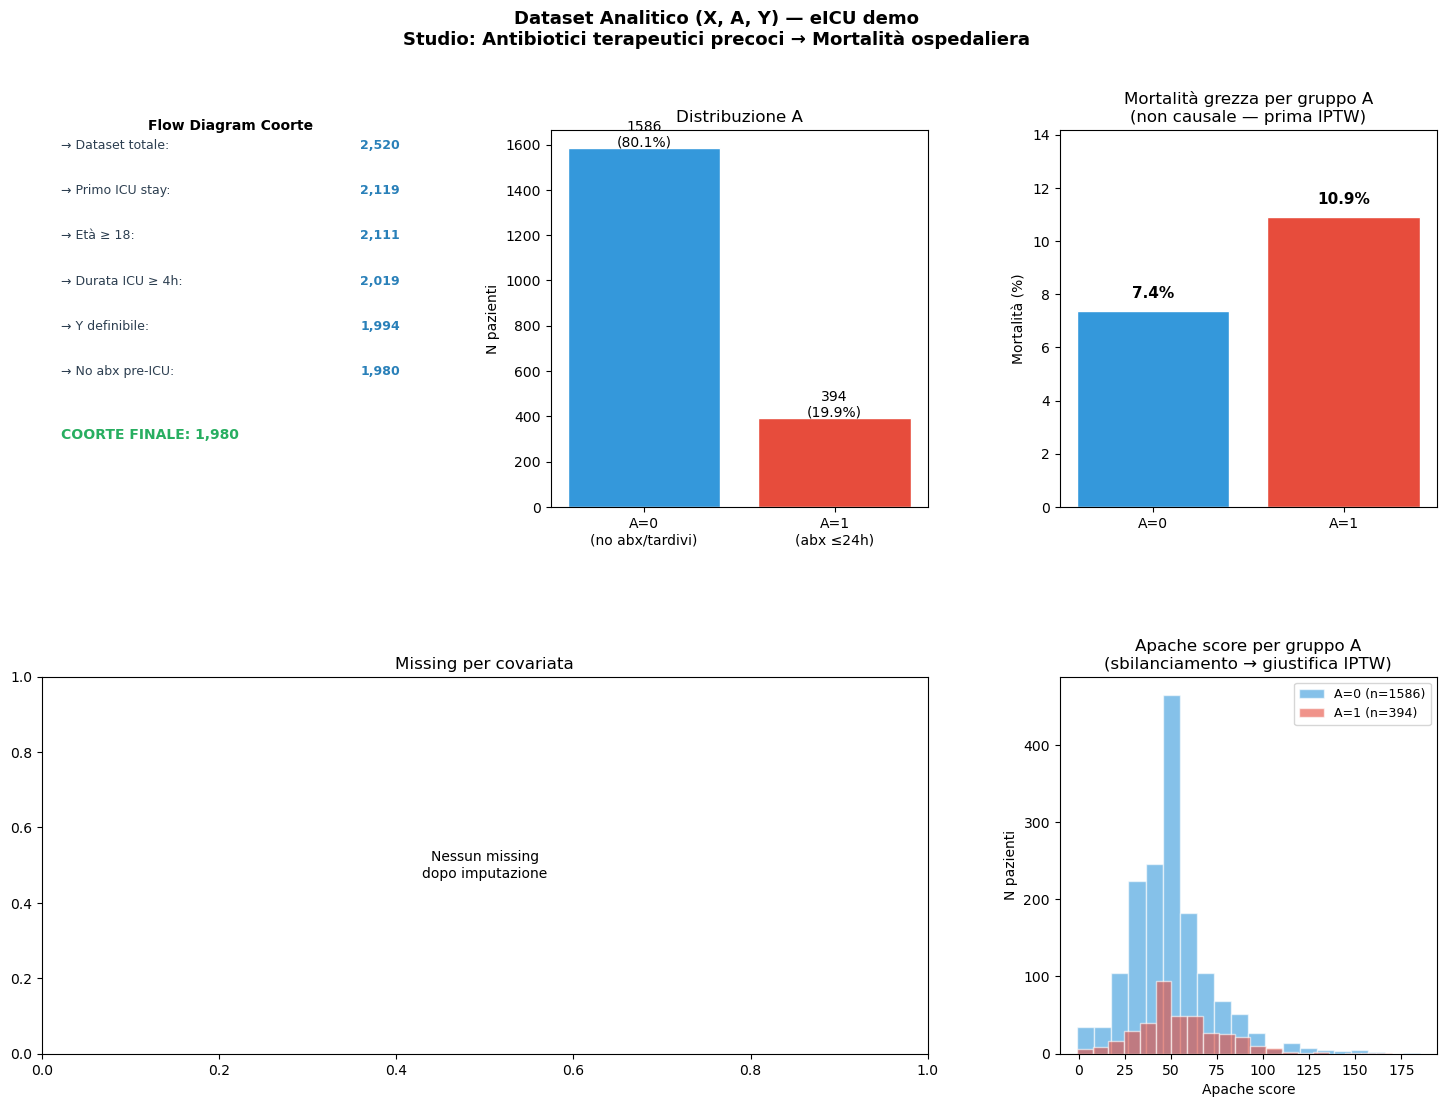

In [11]:
"""
=============================================================
Costruzione Dataset Analitico (X, A, Y) — eICU demo
=============================================================
Domanda causale:
  "Nei pazienti ICU con patologia infettiva/respiratoria,
   la somministrazione di antibiotici terapeutici entro 24h
   dall'ammissione riduce la mortalità ospedaliera?"

  A = antibiotici terapeutici entro 24h  (binario)
  Y = mortalità ospedaliera              (binario)
  X = covariate pre-trattamento basali

Segue il framework Target Trial Emulation (Hernán 2022)
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# 0. CONFIGURAZIONE
# ─────────────────────────────────────────
UP          = "../data/raw/"      # modifica con il tuo path
OUT_PNG     = "../output_png/"
TREAT_WIN   = 24 * 60             # finestra antibiotici (min)
VITAL_WIN   = 120                 # finestra vitali basali (min)
LAB_WIN     = 360                 # finestra lab basali (min) — prime 6h
SEED        = 42

print("=" * 60)
print("STEP 0 — Configurazione")
print(f"  Finestra trattamento: {TREAT_WIN//60}h")
print(f"  Finestra vitali basali: {VITAL_WIN}min")
print(f"  Finestra lab basali: {LAB_WIN}min")

# ─────────────────────────────────────────
# 1. CARICA TABELLE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1 — Caricamento tabelle")
print("=" * 60)

def load(name, usecols=None):
    try:
        df = pd.read_csv(f"{UP}{name}.csv", usecols=usecols)
        print(f"  {name}: {len(df):,} righe, {df.shape[1]} colonne ✅")
        return df
    except FileNotFoundError:
        print(f"  {name}: NON TROVATA ⚠️")
        return None

patient = load("patient",
    ["patientunitstayid","patienthealthsystemstayid","uniquepid",
     "gender","age","ethnicity","hospitalid","unittype",
     "hospitaladmitoffset","hospitaldischargeoffset",
     "hospitaldischargestatus","unitdischargestatus",
     "unitdischargeoffset","unitvisitnumber","admissionweight",
     "admissionheight","apacheadmissiondx","hospitaladmitsource"])

treatment = load("treatment",
    ["patientunitstayid","treatmentoffset","treatmentstring"])

apache_aps = load("apacheApsVar",
    ["patientunitstayid","intubated","vent","dialysis",
     "eyes","motor","verbal","meds","urine","wbc",
     "temperature","respiratoryrate","sodium","heartrate",
     "meanbp","ph","hematocrit","creatinine","albumin",
     "pao2","pco2","bun","glucose","bilirubin","fio2"])

apache_pred = load("apachePredVar",
    ["patientunitstayid","oobintubday1","oobventday1",
     "diabetes","aids","hepaticfailure","lymphoma",
     "metastaticcancer","leukemia","immunosuppression",
     "cirrhosis","electivesurgery","activetx","readmit",
     "diedinhospital"])

apache_res = load("apachePatientResult",
    ["patientunitstayid","apachescore","acutephysiologyscore",
     "predictedhospitalmortality","actualhospitalmortality",
     "apacheversion"])

adm_dx     = load("admissionDx",
    ["patientunitstayid","admitdxpath"])

past_hist  = load("pastHistory",
    ["patientunitstayid","pasthistorypath"])

lab        = load("lab",
    ["patientunitstayid","labresultoffset","labname","labresult"])

vital      = load("vitalPeriodic",
    ["patientunitstayid","observationoffset","temperature",
     "sao2","heartrate","respiration","systemicsystolic",
     "systemicdiastolic","systemicmean"])

diagnosis  = load("diagnosis",
    ["patientunitstayid","diagnosisoffset",
     "diagnosisstring","diagnosispriority"])


# ─────────────────────────────────────────
# 2. STEP 4.1 — SELEZIONE COORTE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — 4.1 Selezione coorte (eligibilità)")
print("=" * 60)

flow = []  # flow diagram

N0 = len(patient)
flow.append(("Dataset totale", N0))

# Primo ICU stay
cohort = patient[patient["unitvisitnumber"] == 1].copy()
flow.append(("Primo ICU stay", len(cohort)))
print(f"\n  Pazienti totali:      {N0:,}")
print(f"  Primo stay:           {len(cohort):,}  "
      f"(-{N0 - len(cohort):,} readmissioni)")

# Età ≥ 18
cohort["age_num"] = cohort["age"].replace("> 89", "90")
cohort["age_num"] = pd.to_numeric(cohort["age_num"], errors="coerce")
n_before = len(cohort)
cohort = cohort[cohort["age_num"] >= 18]
flow.append(("Età ≥ 18", len(cohort)))
print(f"  Età ≥ 18:             {len(cohort):,}  "
      f"(-{n_before - len(cohort):,} pediatrici/unknown)")

# Durata stay ≥ 4h (240 min)
n_before = len(cohort)
cohort = cohort[cohort["unitdischargeoffset"] >= 240]
flow.append(("Durata ICU ≥ 4h", len(cohort)))
print(f"  Durata ICU ≥ 4h:      {len(cohort):,}  "
      f"(-{n_before - len(cohort):,} stay troppo brevi)")

# Y definibile (no missing su hospitaldischargestatus)
n_before = len(cohort)
cohort = cohort[cohort["hospitaldischargestatus"].isin(["Alive","Expired"])]
flow.append(("Y definibile", len(cohort)))
print(f"  Y definibile:         {len(cohort):,}  "
      f"(-{n_before - len(cohort):,} status mancante)")

# Escludi comfort care / EOL (carePlanEOL)
try:
    eol = pd.read_csv(f"{UP}carePlanEOL_csv.gz",
                      usecols=["patientunitstayid"])
    eol_ids = set(eol["patientunitstayid"].unique())
    n_before = len(cohort)
    cohort = cohort[~cohort["patientunitstayid"].isin(eol_ids)]
    flow.append(("No comfort care", len(cohort)))
    print(f"  No comfort care:      {len(cohort):,}  "
          f"(-{n_before - len(cohort):,} EOL)")
except:
    print("  carePlanEOL non disponibile — skip")

N_final = len(cohort)
ids = set(cohort["patientunitstayid"])
print(f"\n  ✅ COORTE FINALE: {N_final:,} pazienti")


# ─────────────────────────────────────────
# 3. STEP 4.3 — DEFINISCI Y
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3 — 4.3 Definizione Y (mortalità ospedaliera)")
print("=" * 60)

cohort["Y"] = (cohort["hospitaldischargestatus"] == "Expired").astype(int)
print(f"\n  Y=1 (morti):      {cohort['Y'].sum():,}  "
      f"({cohort['Y'].mean()*100:.1f}%)")
print(f"  Y=0 (sopravvissuti): {(cohort['Y']==0).sum():,}  "
      f"({(cohort['Y']==0).mean()*100:.1f}%)")


# ─────────────────────────────────────────
# 4. STEP 4.2 — DEFINISCI A
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4 — 4.2 Definizione A (antibiotici terapeutici ≤24h)")
print("=" * 60)

treatment_c = treatment[treatment["patientunitstayid"].isin(ids)].copy()

# Separa terapeutici da profilattici
THERAPEUTIC_KEYWORDS = [
    "therapeutic antibacterials",
    "pulmonary|medications|antibacterials",
    "cardiovascular|other therapies|antibacterials"
]
PROPHYLACTIC_KEYWORDS = [
    "prophylactic"
]

def is_therapeutic(s):
    s = str(s).lower()
    if any(p in s for p in PROPHYLACTIC_KEYWORDS):
        return False
    return any(k in s for k in THERAPEUTIC_KEYWORDS)

treatment_c["is_therapeutic"] = treatment_c["treatmentstring"].apply(
    is_therapeutic)

abx = treatment_c[treatment_c["is_therapeutic"]].copy()
abx["ore"] = abx["treatmentoffset"] / 60

print(f"\n  Record antibiotici terapeutici: {len(abx):,}")
print(f"  Pazienti unici con abx:         "
      f"{abx['patientunitstayid'].nunique():,}")

# Primo antibiotico per paziente
first_abx = (abx.sort_values("treatmentoffset")
               .groupby("patientunitstayid")
               .first()
               .reset_index()
               [["patientunitstayid","treatmentoffset","ore",
                 "treatmentstring"]])
first_abx.columns = ["patientunitstayid","abx_offset",
                     "abx_ore","abx_type"]

# Distribuzione timing
bins   = [-9999, -0.01, 6, 12, 24, 48, 9999]
labels = ["pre-ICU", "0-6h", "6-12h", "12-24h", "24-48h", ">48h"]
first_abx["timing"] = pd.cut(first_abx["abx_ore"],
                              bins=bins, labels=labels)
print(f"\n  Distribuzione timing primo antibiotico:")
print(first_abx["timing"].value_counts().sort_index()
      .rename_axis("timing").reset_index(name="N").to_string(index=False))

# Escludi pre-ICU (offset < 0)
n_before = len(cohort)
pre_icu_abx = set(first_abx[first_abx["abx_offset"] < 0]
                 ["patientunitstayid"])
cohort = cohort[~cohort["patientunitstayid"].isin(pre_icu_abx)]
ids = set(cohort["patientunitstayid"])
flow.append(("No abx pre-ICU", len(cohort)))
print(f"\n  Esclusi abx pre-ICU: {n_before - len(cohort):,} pazienti")

# Definisci A = 1 se primo abx entro 24h
first_abx_valid = first_abx[
    first_abx["patientunitstayid"].isin(ids) &
    (first_abx["abx_offset"] >= 0)
]

cohort = cohort.merge(
    first_abx_valid[["patientunitstayid","abx_offset","abx_ore"]],
    on="patientunitstayid", how="left"
)
cohort["A"] = (
    cohort["abx_offset"].notna() &
    (cohort["abx_offset"] <= TREAT_WIN)
).astype(int)

print(f"\n  A=1 (abx entro 24h):  {cohort['A'].sum():,}  "
      f"({cohort['A'].mean()*100:.1f}%)")
print(f"  A=0 (no abx/tardivi): {(cohort['A']==0).sum():,}  "
      f"({(cohort['A']==0).mean()*100:.1f}%)")

# Mortalità per gruppo
m1 = cohort[cohort["A"]==1]["Y"].mean()*100
m0 = cohort[cohort["A"]==0]["Y"].mean()*100
print(f"\n  Mortalità grezza A=1: {m1:.1f}%")
print(f"  Mortalità grezza A=0: {m0:.1f}%")
print(f"  Differenza grezza:    {m1-m0:+.1f}%  ← non causale!")


# ─────────────────────────────────────────
# 5. STEP 4.4 — ESTRAI X (COVARIATE BASALI)
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5 — 4.4 Estrazione covariate X")
print("=" * 60)

# Parte da cohort per il merge
df = cohort[["patientunitstayid","Y","A",
             "age_num","gender","hospitalid",
             "admissionweight","admissionheight",
             "apacheadmissiondx","hospitaladmitsource"]].copy()

# ── 5a. APACHE APS Var (fisiologia basale)
print("\n  [X] apacheApsVar...")
aps = apache_aps[apache_aps["patientunitstayid"].isin(ids)].copy()
aps_cols = ["patientunitstayid","eyes","motor","verbal",
            "heartrate","meanbp","respiratoryrate",
            "temperature","wbc","creatinine","bun",
            "sodium","glucose","hematocrit","ph",
            "pao2","fio2","urine","bilirubin","albumin"]
aps = aps[aps_cols].groupby("patientunitstayid").first().reset_index()
aps.columns = ["patientunitstayid"] + \
    [f"aps_{c}" for c in aps_cols[1:]]
df = df.merge(aps, on="patientunitstayid", how="left")
print(f"    {len(aps_cols)-1} variabili aggiunte")

# ── 5b. APACHE Score (gravità complessiva)
print("  [X] apachePatientResult (Apache score)...")
if apache_res is not None:
    ares = apache_res[
        apache_res["patientunitstayid"].isin(ids)
    ][["patientunitstayid","apachescore",
       "acutephysiologyscore","predictedhospitalmortality"]].copy()
    # Tieni solo Apache IV (versione più recente)
    ares = ares.groupby("patientunitstayid").first().reset_index()
    df = df.merge(ares, on="patientunitstayid", how="left")
    print(f"    apachescore, acutephysiologyscore, "
          f"predictedhospitalmortality aggiunti")

# ── 5c. APACHE PredVar (comorbidità)
print("  [X] apachePredVar (comorbidità)...")
if apache_pred is not None:
    apred = apache_pred[
        apache_pred["patientunitstayid"].isin(ids)
    ].copy()
    comorbidity_cols = ["patientunitstayid",
        "diabetes","aids","hepaticfailure","lymphoma",
        "metastaticcancer","leukemia","immunosuppression",
        "cirrhosis","electivesurgery"]
    apred = apred[comorbidity_cols].groupby(
        "patientunitstayid").first().reset_index()
    df = df.merge(apred, on="patientunitstayid", how="left")
    print(f"    {len(comorbidity_cols)-1} comorbidità aggiunte")

# ── 5d. VITALI BASALI (prime 2h)
print(f"  [X] vitalPeriodic (prime {VITAL_WIN}min)...")
if vital is not None:
    vit = vital[
        vital["patientunitstayid"].isin(ids) &
        (vital["observationoffset"] >= 0) &
        (vital["observationoffset"] <= VITAL_WIN)
    ].copy()
    vit_agg = vit.groupby("patientunitstayid").agg(
        vital_sao2_min   =("sao2",            "min"),
        vital_sao2_mean  =("sao2",            "mean"),
        vital_hr_mean    =("heartrate",        "mean"),
        vital_rr_mean    =("respiration",      "mean"),
        vital_sbp_mean   =("systemicsystolic", "mean"),
        vital_dbp_mean   =("systemicdiastolic","mean"),
        vital_map_mean   =("systemicmean",     "mean"),
        vital_temp_mean  =("temperature",      "mean"),
    ).reset_index()
    df = df.merge(vit_agg, on="patientunitstayid", how="left")
    print(f"    8 variabili vitali aggiunte")

# ── 5e. LAB BASALI (prime 6h)
print(f"  [X] lab (prime {LAB_WIN}min)...")
if lab is not None:
    lab_c = lab[
        lab["patientunitstayid"].isin(ids) &
        (lab["labresultoffset"] >= 0) &
        (lab["labresultoffset"] <= LAB_WIN)
    ].copy()
    # Seleziona lab clinicamente rilevanti
    LAB_INTEREST = {
        "lactate":      "lab_lactate",
        "WBC x 1000":   "lab_wbc",
        "creatinine":   "lab_creatinine",
        "bicarbonate":  "lab_bicarbonate",
        "glucose":      "lab_glucose",
        "Hgb":          "lab_hgb",
        "platelets x 1000": "lab_platelets",
        "sodium":       "lab_sodium",
        "potassium":    "lab_potassium",
        "BUN":          "lab_bun",
        "total bilirubin": "lab_bilirubin",
    }
    for lab_name, col_name in LAB_INTEREST.items():
        lab_sub = (lab_c[lab_c["labname"] == lab_name]
                   .sort_values("labresultoffset")
                   .groupby("patientunitstayid")["labresult"]
                   .first()
                   .reset_index()
                   .rename(columns={"labresult": col_name}))
        df = df.merge(lab_sub, on="patientunitstayid", how="left")
    print(f"    {len(LAB_INTEREST)} lab aggiunti")

# ── 5f. DIAGNOSI DI AMMISSIONE (flag infettiva)
print("  [X] admissionDx (diagnosi ammissione)...")
if adm_dx is not None:
    adx_c = adm_dx[adm_dx["patientunitstayid"].isin(ids)].copy()
    # Flag diagnosi infettiva/respiratoria
    adx_c["infective_dx"] = adx_c["admitdxpath"].str.lower().str.contains(
        "sepsis|infect|pneumon|bacteremia|respiratory",
        na=False
    ).astype(int)
    adx_c["cardiac_dx"] = adx_c["admitdxpath"].str.lower().str.contains(
        "cardiovascular|cardiac|arrhythmia|heart",
        na=False
    ).astype(int)
    adx_c["neuro_dx"] = adx_c["admitdxpath"].str.lower().str.contains(
        "neurolog|coma|seizure|stroke",
        na=False
    ).astype(int)
    adx_agg = adx_c.groupby("patientunitstayid").agg(
        infective_dx=("infective_dx","max"),
        cardiac_dx  =("cardiac_dx",  "max"),
        neuro_dx    =("neuro_dx",    "max"),
    ).reset_index()
    df = df.merge(adx_agg, on="patientunitstayid", how="left")
    print(f"    3 flag diagnosi aggiunti")
    n_infective = df["infective_dx"].fillna(0).sum()
    print(f"    Pazienti con diagnosi infettiva/resp: {n_infective:.0f}")

# ── 5g. COMORBIDITÀ DA pastHistory
print("  [X] pastHistory (comorbidità)...")
if past_hist is not None:
    ph_c = past_hist[
        past_hist["patientunitstayid"].isin(ids)
    ].copy()
    ph_c["htn"] = ph_c["pasthistorypath"].str.lower().str.contains(
        "hypertension", na=False).astype(int)
    ph_c["chf"] = ph_c["pasthistorypath"].str.lower().str.contains(
        "heart failure|chf", na=False).astype(int)
    ph_c["copd"] = ph_c["pasthistorypath"].str.lower().str.contains(
        "copd", na=False).astype(int)
    ph_c["ckd"] = ph_c["pasthistorypath"].str.lower().str.contains(
        "renal|kidney", na=False).astype(int)
    ph_agg = ph_c.groupby("patientunitstayid").agg(
        hx_htn =("htn", "max"),
        hx_chf =("chf", "max"),
        hx_copd=("copd","max"),
        hx_ckd =("ckd", "max"),
    ).reset_index()
    df = df.merge(ph_agg, on="patientunitstayid", how="left")
    print(f"    4 comorbidità da pastHistory aggiunte")


# ─────────────────────────────────────────
# 6. STEP 4.5 — GESTIONE MISSING
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6 — 4.5 Gestione missing")
print("=" * 60)

# Calcola percentuale missing per colonna
miss_pct = df.isnull().mean() * 100
print("\n  Missing per colonna (solo >0%):")
miss_report = miss_pct[miss_pct > 0].sort_values(ascending=False)
for col, pct in miss_report.items():
    flag = "❌ >40%" if pct > 40 else ("⚠️ >10%" if pct > 10 else "✅")
    print(f"    {col:<35} {pct:5.1f}%  {flag}")

# Identifica covariate numeriche e categoriche
id_cols    = ["patientunitstayid"]
target_cols = ["Y", "A"]
cat_cols   = ["gender","hospitalid","apacheadmissiondx",
              "hospitaladmitsource"]
bin_cols   = ["diabetes","aids","hepaticfailure","lymphoma",
              "metastaticcancer","leukemia","immunosuppression",
              "cirrhosis","electivesurgery","oobintubday1",
              "infective_dx","cardiac_dx","neuro_dx",
              "hx_htn","hx_chf","hx_copd","hx_ckd"]
num_cols   = [c for c in df.columns
              if c not in id_cols + target_cols + cat_cols + bin_cols]

# Imputazione: mediana per numeriche, moda per categoriche
print("\n  Imputazione:")
print("    Numeriche → mediana")
print("    Categoriche → moda")
print("    Binarie → 0 (assenza)")

df_imp = df.copy()

for col in num_cols:
    if df_imp[col].isnull().any():
        med = df_imp[col].median()
        df_imp[f"{col}_missing"] = df_imp[col].isnull().astype(int)
        df_imp[col] = df_imp[col].fillna(med)

for col in cat_cols:
    if col in df_imp.columns and df_imp[col].isnull().any():
        mode = df_imp[col].mode()[0] if len(df_imp[col].mode()) > 0 else "Unknown"
        df_imp[col] = df_imp[col].fillna(mode)

for col in bin_cols:
    if col in df_imp.columns:
        df_imp[col] = df_imp[col].fillna(0).astype(int)

# Encoding categoriche
df_imp["gender_male"] = (df_imp["gender"] == "Male").astype(int)

print(f"\n  Dataset finale dopo imputazione:")
print(f"    Righe:   {len(df_imp):,}")
print(f"    Colonne: {df_imp.shape[1]:,}")
print(f"    Missing residui: {df_imp.isnull().sum().sum()}")


# ─────────────────────────────────────────
# 7. STEP 4.6 — FEATURE LIST FINALE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7 — Feature list finale")
print("=" * 60)

feature_groups = {
    "Demografiche": ["age_num","gender_male","admissionweight",
                     "admissionheight"],
    "Gravità (Apache)": ["apachescore","acutephysiologyscore",
                          "predictedhospitalmortality",
                          "aps_heartrate","aps_meanbp",
                          "aps_respiratoryrate","aps_temperature",
                          "aps_ph","aps_pao2","aps_fio2",
                          "aps_creatinine","aps_sodium",
                          "aps_glucose","aps_hematocrit",
                          "aps_wbc","aps_urine","aps_albumin"],
    "GCS (Apache)": ["aps_eyes","aps_motor","aps_verbal"],
    "Vitali basali (2h)": [c for c in df_imp.columns
                            if c.startswith("vital_")],
    "Lab basali (6h)": [c for c in df_imp.columns
                         if c.startswith("lab_")],
    "Diagnosi ammissione": ["infective_dx","cardiac_dx","neuro_dx"],
    "Comorbidità (apache)": ["diabetes","cirrhosis","hepaticfailure",
                              "immunosuppression","metastaticcancer",
                              "leukemia","lymphoma","aids"],
    "Comorbidità (storia)": ["hx_htn","hx_chf","hx_copd","hx_ckd"],
    "Ospedale": ["hospitalid"],
}

total_features = 0
for group, cols in feature_groups.items():
    available = [c for c in cols if c in df_imp.columns]
    total_features += len(available)
    print(f"  {group}: {len(available)} variabili")
    for c in available:
        miss = df_imp[c].isnull().mean()*100
        print(f"    - {c:<40} missing: {miss:.1f}%")

print(f"\n  TOTALE FEATURES: {total_features}")
print(f"  A (esposizione): A")
print(f"  Y (outcome):     Y")


# ─────────────────────────────────────────
# 8. SALVA DATASET
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 8 — Salvataggio")
print("=" * 60)

# Seleziona colonne finali
all_feature_cols = [c for cols in feature_groups.values()
                    for c in cols if c in df_imp.columns]
# Aggiungi indicatori missing
missing_indicators = [c for c in df_imp.columns
                      if c.endswith("_missing")]
final_cols = (["patientunitstayid","Y","A"] +
              all_feature_cols + missing_indicators)
final_cols = [c for c in final_cols if c in df_imp.columns]

df_final = df_imp[final_cols].copy()
df_final.to_csv("../data/processed/dataset_XAY.csv", index=False)
print(f"\n  Salvato: dataset_XAY.csv")
print(f"  Shape: {df_final.shape}")

# Descrittive per gruppo A
print("\n  Statistiche descrittive per gruppo A:")
desc = df_final.groupby("A").agg(
    N=("Y","count"),
    mortalita_pct=("Y","mean"),
    age_media=("age_num","mean"),
    apache_medio=("apachescore","mean"),
).round(2)
desc["mortalita_pct"] *= 100
print(desc.to_string())


# ─────────────────────────────────────────
# 9. FIGURE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 9 — Figure")
print("=" * 60)

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Dataset Analitico (X, A, Y) — eICU demo\n"
             "Studio: Antibiotici terapeutici precoci → Mortalità ospedaliera",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Flow diagram coorte
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis("off")
y_pos = 0.95
ax1.text(0.5, 1.0, "Flow Diagram Coorte",
         ha="center", fontweight="bold", transform=ax1.transAxes)
for label, n in flow:
    ax1.text(0.05, y_pos, f"→ {label}:", transform=ax1.transAxes,
             fontsize=9, color="#2c3e50")
    ax1.text(0.95, y_pos, f"{n:,}", transform=ax1.transAxes,
             fontsize=9, ha="right", color="#2980b9", fontweight="bold")
    y_pos -= 0.12
ax1.text(0.05, y_pos-0.05,
         f"COORTE FINALE: {len(df_final):,}",
         transform=ax1.transAxes, fontsize=10,
         color="#27ae60", fontweight="bold")

# Plot 2: Distribuzione A
ax2 = fig.add_subplot(gs[0, 1])
counts = df_final["A"].value_counts().sort_index()
bars = ax2.bar(["A=0\n(no abx/tardivi)", "A=1\n(abx ≤24h)"],
               counts.values,
               color=["#3498db","#e74c3c"], edgecolor="white")
ax2.set_title("Distribuzione A")
ax2.set_ylabel("N pazienti")
for bar, v in zip(bars, counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f"{v}\n({v/len(df_final)*100:.1f}%)",
             ha="center", fontsize=10)

# Plot 3: Mortalità per gruppo A
ax3 = fig.add_subplot(gs[0, 2])
mort = df_final.groupby("A")["Y"].mean() * 100
ax3.bar(["A=0", "A=1"], mort.values,
        color=["#3498db","#e74c3c"], edgecolor="white")
ax3.set_title("Mortalità grezza per gruppo A\n(non causale — prima IPTW)")
ax3.set_ylabel("Mortalità (%)")
ax3.set_ylim(0, mort.max()*1.3)
for i, v in enumerate(mort.values):
    ax3.text(i, v+0.5, f"{v:.1f}%", ha="center", fontsize=11,
             fontweight="bold")

# Plot 4: Missing heatmap
ax4 = fig.add_subplot(gs[1, 0:2])
miss_data = df_final[all_feature_cols].isnull().mean() * 100
miss_data = miss_data[miss_data > 0].sort_values(ascending=True)
if len(miss_data) > 0:
    colors = ["#e74c3c" if v>40 else "#f39c12" if v>10 else "#2ecc71"
              for v in miss_data.values]
    ax4.barh(miss_data.index, miss_data.values, color=colors)
    ax4.axvline(10, color="orange", linestyle="--",
                alpha=0.7, label="10%")
    ax4.axvline(40, color="red", linestyle="--",
                alpha=0.7, label="40%")
    ax4.set_title("Missing per covariata")
    ax4.set_xlabel("% Missing")
    ax4.legend(fontsize=8)
else:
    ax4.text(0.5, 0.5, "Nessun missing\ndopo imputazione",
             ha="center", va="center", transform=ax4.transAxes)
    ax4.set_title("Missing per covariata")

# Plot 5: Apache score per gruppo A
ax5 = fig.add_subplot(gs[1, 2])
if "apachescore" in df_final.columns:
    for a_val, color, label in [(0,"#3498db","A=0"),(1,"#e74c3c","A=1")]:
        data = df_final[df_final["A"]==a_val]["apachescore"].dropna()
        ax5.hist(data, bins=20, alpha=0.6, color=color,
                 label=f"{label} (n={len(data)})", edgecolor="white")
    ax5.set_title("Apache score per gruppo A\n"
                  "(sbilanciamento → giustifica IPTW)")
    ax5.set_xlabel("Apache score")
    ax5.set_ylabel("N pazienti")
    ax5.legend(fontsize=9)

plt.savefig(f"{OUT_PNG}dataset_XAY_summary.png",
            dpi=150, bbox_inches="tight")
print(f"\n  Figura salvata: dataset_XAY_summary.png")
print("\n✅ Script completato — Dataset pronto per IPTW + AIPW")